# Physically motivated phase curve models I: thermal phase curve

This notebook demonstrate the modelling of a thermal phase curve to TESS observations. We will use thermal phase curve model from [`kelp`](https://kelp.readthedocs.io/en/latest/api/kelp.jax.thermal_phase_curve.html#kelp.jax.thermal_phase_curve) package. This is a physically motivated thermal phase curve model that first generates a temperature map, and subsequently uses the temperature map to generate phase curve model. The temperature map is generated using the spherical harmonics. Once we fit the phase curve model, we can invert the model to find the temperature map of the planet. We can then use the temperature map to compute the Bond albedo and heat re-distribution efficiency of the planet. See [Morris et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...660A.123M/abstract) for details on the phase curve model.

To enable this phase curve model, we need to provide priors on the following five phase curve parameters:
1) `hotspotoff_p1_instruments`: Angle of hotspot offset from the local noon (in degrees)
2) `wdrag_p1_instruments`: Dimensionless drag frequency (typically, this is fixed to 4.5; see [Morris et al. 2022](https://ui.adsabs.harvard.edu/abs/2022A%26A...660A.123M/abstract) for an explanation)
3) `alpha_p1_instruments`: Dimensionless fluid number (typically, we can fix this to 0.6; see [Morris et al. 2022](https://ui.adsabs.harvard.edu/abs/2022A%26A...660A.123M/abstract) for an explanation)
4) `cml11_p1_instruments`: Spherical harmonic power in the $m=1$, $l=1$ mode
5) `fprime_p1_instruments`: Greenhouse parameter (typically $\sim 1/\sqrt{2}$).

Note that all of these five parameters are planetary _and_ instrumental parameters. Therefore, we can share them over multiple instruments. Please keep in mind that if you share one parameter for multiple instruments, you have to share all other parameters for those same instruments as well. In the present notebook, we will only use data from one instrument, so we don't need to specify the instrument name (well, we _can_ specify even just one instrument name, but it doesn't matter. See `multi_instruments.ipynb` for more details on this).

In addition to these parameters, we have to provide the following information in `juliet.fit`:
- `stellar_teff`: Effective temperature of the star (in K)
- Transmission function for each instrument: `kelp_filt_wav` and `kelp_filt_trans` keywords take dictionaries with wavelengths (in m) and transmission functions for each instruments. The keys of both dictionaries should be the name of instruments.
- As mentioned before, `kelp` generates temperature map to calculate phase curve model. It internally generates this temperature map on a spherical grid. We can provide number of grid points along latitude and longitude to do this: `kelp_ntheta` (latitude grid points, default is 5) and `kelp_nphi` (longitude grid points, default is 75). Since the latitudinal information is challenging to get from phase curve, it makes sense to make the grid sparse along latitude.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gd
from kelp.jax import thermal_phase_curve
from kelp import Filter
from kelp import Model
import astropy.constants as con
from tqdm import tqdm
import seaborn as sns
import plotstyles
import juliet
import os

from matplotlib import rcParams
rcParams['legend.frameon']= True

## I have MacBook Pro with M1 chip, so I need following two lines for multiprocessing to work
import multiprocessing
multiprocessing.set_start_method('fork')

print('juliet version:', juliet.__version__)

juliet version: 2.2.9


We will use the TESS observations of an ultra-hot Jupiter KELT-9 b in Sector 82 to fit the thermal phase curve. The equilibrium temperature of the planet is 4050 K ([Gaudi et al. 2017](https://ui.adsabs.harvard.edu/abs/2017Natur.546..514G/abstract)). At such a higher temperature, we will mainly see the thermal emission even in TESS bandpass. Therefore, our choice of thermal phase curve is justified. [Jones et al. 2022](https://ui.adsabs.harvard.edu/abs/2022A%26A...666A.118J/abstract) used some of the TESS observations to constrain the thermal phase curve of the planet.

Let's first load some planetary parameters:

In [2]:
# And priros
## We need planetary and stellar parameters for this (all parameters are from Gaudi et al. 2017)
per, per_err = 1.4811235, 0.0000011             # Orbital period in days
t0, t0_err = 2457095.68572, 0.00014             # Transit epoch in BJD
rprs, rprs_err = 0.08228, 0.00043               # Planet-to-star radius ratio
b, b_err = 0.177, 0.014                         # Impact parameter
rho, rho_err = 0.2702*1e3, 0.0029*1e3           # Stellar density in kg/m3

And data:

(0.0, 25.852666205260903)

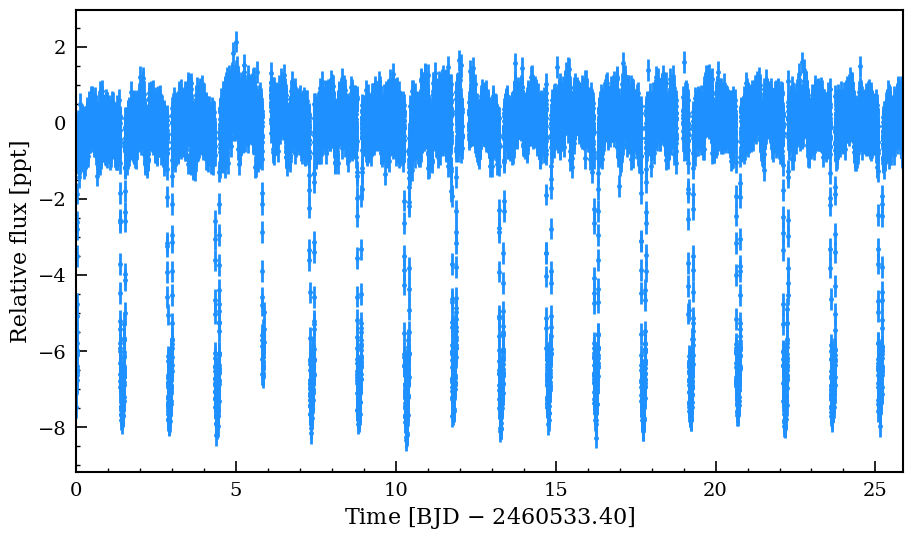

In [3]:
tim82, fl82, fle82 = np.loadtxt(os.getcwd() + '/Data/KELT-9_TESS82.dat',\
                                usecols=(0,1,2), unpack=True)

# Ploting the data
fig, axs = plt.subplots()
axs.errorbar(tim82-tim82[0], (fl82-1)*1e3, yerr=fle82*1e3, fmt='.', color='dodgerblue')
axs.set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim82[0]))
axs.set_ylabel('Relative flux [ppt]')
axs.set_xlim([0., np.max(tim82-tim82[0])])

We will need the transmission function of TESS bandpass:

In [4]:
# And now loading transmission function
## TESS
wav, trans = np.loadtxt(os.getcwd() + '/Data/tess_response_fun.txt', usecols=(0,1), unpack=True)
## Saving it in dict, keys are instrument name
filt_wav, filt_trans = {}, {}
filt_wav['TESS82'], filt_trans['TESS82'] = wav, trans

We now generate priors. As said, we need to specify priors five additional parameters (`hotspotoff_p1`, `wdrag_p1`, `alpha_p1`, `cml11_p1`, and `fprime_p1`) to enable thermal phase curve fitting. Since there is only one instrument, we do not need to specify the instrument name to these parameters. Among these, we will fix `wdrag_p1` and `alpha_p1` to their recommended values from [Morris et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...660A.123M/abstract). Finally, we will use Gaussian process (SHO kernel) to model the additional systematics in the dataset.

In [5]:
# Instrument name
instrument = 'TESS82'

# Creating data dictionaries the way juliet understands
tim, fl, fle = {}, {}, {}
tim[instrument], fl[instrument], fle[instrument] = tim82, fl82, fle82

### Predicting transit and occultation time for our observations
cycle = round((tim82[0] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_' + instrument, 'q2_' + instrument, 'ecc_p1', 'omega_p1', 'rho']
dist_P = ['normal', 'normal', 'normal', 'normal', 'uniform', 'uniform', 'fixed', 'fixed', 'normal']
hyper_P = [[per, per_err], [tc, tc_err], [rprs, 3*rprs_err], [b, 3*b_err], [0., 1.], [0., 1.], 0., 90., [rho, rho_err]]
## Phase curve priors
par_pc = ['hotspotoff_p1', 'wdrag_p1', 'alpha_p1', 'cml11_p1', 'fprime_p1']
dist_pc = ['uniform', 'fixed', 'fixed', 'uniform', 'uniform']
hyper_pc = [[-30., 30.], 4.5, 0.6, [0., 0.5], [0.65, 0.8]]

## Instrumental priors
par_ins = ['mdilution_' + instrument, 'mflux_' + instrument, 'sigma_w_' + instrument]
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1.0, [0., 0.1], [0.1, 10000]]

## GP priors
par_gp = ['GP_S0_' + instrument, 'GP_omega0_' + instrument, 'GP_Q_' + instrument]
dist_gp = ['uniform', 'uniform', 'fixed']
hyper_gp = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]

# Total priors
par_tot = par_P + par_pc + par_ins + par_gp
dist_tot = dist_P + dist_pc + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_pc + hyper_ins + hyper_gp

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And, let's fit the data now! Remember, we need to specify stellar effective temperature, filter wavelenghts and transmission functions to `juliet.fit`, as shown below. We will leave `kelp_ntheta` and `kelp_nphi` to their default values.

**Please note that this fitting can take several hours to finish.**

As it can take hours to finish this fitting, we might want to stop the sampler and resume it again after a while. Since `juliet` v2.2.9, this would be possible for `dynesty` and `dynamic_dynesty` samplers. By setting `dynesty_save_states` keyword in `juliet.fit` to `True`, we can tell `dynesty` to save the state of the sampler at every fixed time interval. User can give this fixed time interval using `checkpoint_every` keyword of `juliet.fit`. Please note that the time interval is in seconds. This will save the state of sampler at every fixed interval in a pickle file in output directory.

To resume sampler after an interruption, user simply needs to set `dynesty_resume` keyword in `juliet.fit` to `True`.

In [6]:
# Output folder
pout = os.getcwd() + '/Analysis/Kelp_thm'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                   GP_regressors_lc=tim, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True, stellar_radius=2.362,\
               stellar_teff=10170, kelp_filt_wav=filt_wav, kelp_filt_trans=filt_trans,\
               dynesty_save_states=True, checkpoint_every=5*60)#, dynesty_resume=True)

Detected dynamic_dynesty sampler output files --- extracting from /Users/japa6985/Documents/Codes/juliet-examples/Analysis/Kelp_thm/_dynesty_DNS_posteriors.pkl


Now, we want to plot the dataset along with best-fitted models. For that, we first need to compute the models:

In [7]:
# --------------------------------------------
#    Some planetary models
# --------------------------------------------
## Mflux and sigma_w (white noise)
mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)
P_post = np.nanmedian(res.posteriors['posterior_samples']['P_p1'])
t0_post = np.nanmedian(res.posteriors['posterior_samples']['t0_p1'])

# --------------------------------------------
#    Extracting all models
# --------------------------------------------
# Creating all models
model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
## Saving all models
all_models = res.lc.model[instrument]

# --------------------------------------------
#    Full fitted models
# --------------------------------------------
# Full fitted model:
full_median_model = model[1]
## Sample random full model (to show uncertainties)
sample_models = model[0]
idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
random_models = sample_models[idx_nsamps, :]

# --------------------------------------------
#    Detrended data
# --------------------------------------------
## GP model
gp_median_model = all_models['GP']
## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
## See, juliet paper to find their meanings
F1 = np.nanmedian( 1 / ( 1 + mflx ) )
F2 = 0.

# Detrended data and errors
detrended_data = ( fl82 - gp_median_model ) / F1 
detrended_errors = np.sqrt( fle82**2 + sigw**2 )
# Orbital phases (for phase curve)
phases = juliet.utils.get_phases(t=tim82, P=P_post, t0=t0_post, phmin=0.8)

# --------------------------------------------
#    Detrended models
# --------------------------------------------
# Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
post_samps_new = res.posteriors['posterior_samples'].copy()
for i in post_samps_new.keys():
    if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
        post_samps_new[i] = np.zeros(len(post_samps_new[i]))

planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                     return_components=True, return_samples=True, evaluate_transit=True)

# Sorting indices according to orbital phases
idx_phs = np.argsort(phases)

# Detrended median model
detrended_median_model = planet_only_models[1][idx_phs]
## Corresponding phases
phases_of_detrended_model = phases[idx_phs]
## Random models to show uncertainties
sample_pl_models = planet_only_models[0][:, idx_phs]
idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
random_pl_models = sample_pl_models[idx_nsamps_pl, :]

# --------------------------------------------
#    Binned data for visuals
# --------------------------------------------
# Residuals and binned data
resids = fl82 - full_median_model

# Binned data (for phase curves)
bin_phs, bin_det, bin_deterr = juliet.utils.bin_data(x=phases[idx_phs], y=detrended_data[idx_phs], n_bin=400, yerr=detrended_errors[idx_phs])
_, bin_res, bin_reserr = juliet.utils.bin_data(x=phases[idx_phs], y=resids[idx_phs], n_bin=400, yerr=detrended_errors[idx_phs])

And finally the plotting:

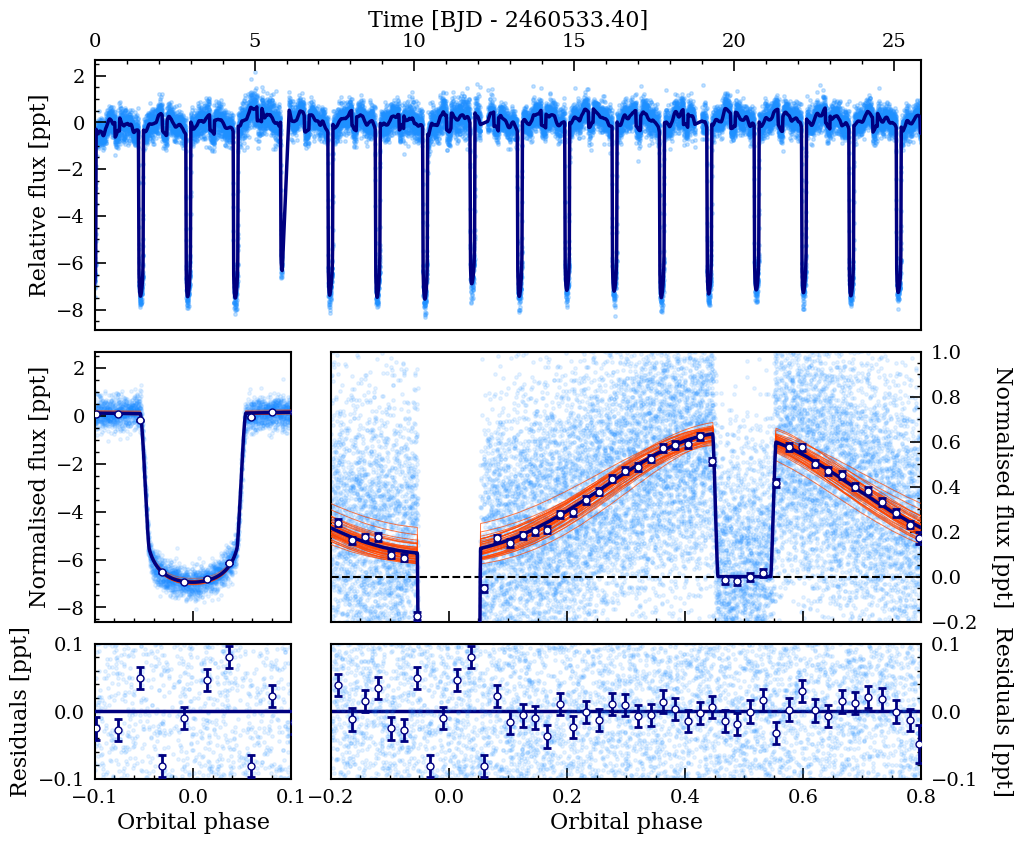

In [8]:
fig = plt.figure(figsize=(16/1.5, 14/1.5))
gs = gd.GridSpec(3, 2, height_ratios=[6,6,3], width_ratios=[1,3], hspace=0.1, wspace=0.1)

ax0 = plt.subplot(gs[0,:])
ax0.errorbar(tim82-tim82[0], (fl82-1.)*1e3, fmt='.', alpha=0.25, c='dodgerblue', zorder=1)
ax0.plot(tim82-tim82[0], (full_median_model-1.)*1e3, c='navy', lw=2.5, zorder=50)
for rand in range(100):
    ax0.plot(tim82-tim82[0], (random_models[rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)

ax0.set_ylabel('Relative flux [ppt]')
ax0.set_xlabel('Time [BJD - {:.2f}]'.format(tim82[0]))
ax0.xaxis.tick_top()
ax0.xaxis.set_label_position('top')
ax0.set_xlim([0., np.max(tim82-tim82[0])])
#ax0.xaxis.set_major_formatter(plt.NullFormatter())

# Transit
xlim1, xlim2 = -0.1, 0.1
## -- Upper panel
ax1 = plt.subplot(gs[1,0])
ax1.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.1, c='dodgerblue', zorder=1)
ax1.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax1.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, color='navy', lw=2.5, zorder=50)
for i in range(50):
    ax1.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, color='orangered', alpha=0.5, lw=0.7, zorder=10)

ax1.set_ylabel('Normalised flux [ppt]')
ax1.set_xlim([xlim1, xlim2])
ax1.xaxis.set_major_formatter(plt.NullFormatter())

## -- Bottom panel
ax2 = plt.subplot(gs[2,0])
ax2.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', alpha=0.1, c='dodgerblue')
ax2.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=20)
ax2.axhline(0.0, lw=2.5, color='navy', zorder=10)

ax2.set_xlabel('Orbital phase')
ax2.set_ylabel('Residuals [ppt]')
ax2.set_xlim([xlim1, xlim2])
ax2.set_ylim([-0.1, 0.1])


# Phase curve
xlim3, xlim4 = -0.2, 0.8

## Upper panel
ax3 = plt.subplot(gs[1,1])
ax3.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.1, c='dodgerblue', zorder=1)
ax3.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax3.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, c='navy', lw=2.5, zorder=50)
ax3.axhline(0., color='k', ls='--', lw=1.5, zorder=25)
for i in range(50):
    ax3.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, c='orangered', alpha=0.7, lw=0.7, zorder=10)

ax3.set_ylabel('Normalised flux [ppt]', rotation=270, labelpad=25)
ax3.set_xlim([xlim3, xlim4])
ax3.set_ylim([-0.2, 1.])
ax3.yaxis.tick_right()
ax3.tick_params(labelright=True)
ax3.yaxis.set_label_position('right')
ax3.xaxis.set_major_formatter(plt.NullFormatter())

## Bottom panel
ax4 = plt.subplot(gs[2,1])
ax4.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', color='dodgerblue', alpha=0.1)
ax4.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax4.axhline(0., lw=2.5, color='navy')

ax4.set_xlabel('Orbital phase')
ax4.set_ylabel('Residuals [ppt]', rotation=270, labelpad=25)
ax4.set_xlim([xlim3, xlim4])
ax4.set_ylim([-0.1, 0.1])
ax4.yaxis.tick_right()
ax4.tick_params(labelright=True, labelfontfamily='serif')
ax4.yaxis.set_label_position('right')

plt.tight_layout()

We can clearly see an occultation even in the raw data. In above plots, the light blue points are the un-binned data points, while the blue open circles are binned data points. The solid blue line is the median fitted model, while the orange lines are the models computed from the randomly selected posteriors. The dashed black line in the middle right panel is the baseline flux level. It is set to the flux from the system during the occultation (i.e., stellar flux level).

The occultation depth is seem to be around 0.6-0.7 ppt (i.e., 600-700 ppm), which is close to what was reported in [Jones et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...666A.118J/abstract). We can compare our values of phase curve parameters with the published values. Let's look at the posteriors of `hotspotoff_p1`, `cml11_p1`, and `fprime_p1`:

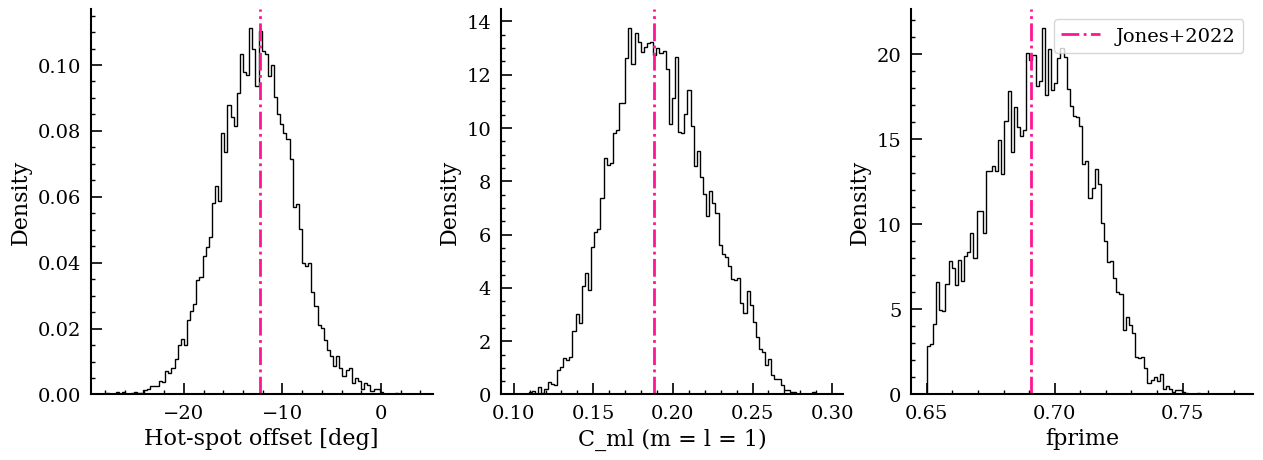

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
axs[0].hist(res.posteriors['posterior_samples']['hotspotoff_p1'], color='k', bins=100, histtype='step', density=True);
axs[0].axvline(-12.32, color='deeppink', ls='-.', label='Jones+2022')
axs[0].set_xlabel('Hot-spot offset [deg]')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['cml11_p1'], color='k', bins=100, histtype='step', density=True);
axs[1].axvline(0.1884, color='deeppink', ls='-.')
axs[1].set_xlabel('C_ml (m = l = 1)')
axs[1].set_ylabel('Density')

axs[2].hist(res.posteriors['posterior_samples']['fprime_p1'], color='k', bins=100, histtype='step', density=True);
axs[2].axvline(0.690798, color='deeppink', ls='-.', label='Jones+2022')
axs[2].set_xlabel('fprime')
axs[2].set_ylabel('Density')
axs[2].legend(loc='upper right')

sns.despine()

Neat! The posterior distribution almost perfectly agrees with their corresponding values from [Jones et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...666A.118J/abstract). Okay, now that we have phase curve parameters, we can invert this phase curve to find the temperature map, Bond albedo, and heat re-distribution efficiency:

In [10]:
# TESS Filter 
filt_kelp = Filter.from_name("TESS")

# First we need to compute a/R* from rho and P
G = con.G.value    # Gravitational constant
ar = (( res.posteriors['posterior_samples']['rho'] * G * ((res.posteriors['posterior_samples']['P_p1'] * 24. * 3600.)**2)) / (3. * np.pi))**(1. / 3.)
## This is Rp/a = Rp_R* / a_R*
Rpa = res.posteriors['posterior_samples']['p_p1'] / ar

## To randomly select 1000 samples
idx1 = np.random.choice( np.arange(len(ar)), size=10000, replace=False )

## Bond albedo and heat redistribution efficiency
A_b, eps = np.zeros(10000), np.zeros(10000)
for i in tqdm(range(len(idx1))):
    ## C_ml coefficients
    Cml = [[0],
           [0, res.posteriors['posterior_samples']['cml11_p1'][idx1[i]], 0]]
    
    ## Computing models
    model = Model(hotspot_offset=res.posteriors['posterior_samples']['hotspotoff_p1'][idx1[i]],\
                  alpha=0.6, omega_drag=4.5, A_B=0., C_ml=Cml, lmax=1,\
                  a_rs=ar[idx1[i]], rp_a=Rpa[idx1[i]], T_s=10170, filt=filt_kelp)
    
    ## Compute the temperature map:
    Tmap, theta, phi = model.temperature_map(n_theta=100, n_phi=100,\
                                             f=res.posteriors['posterior_samples']['fprime_p1'][idx1[i]])

    # Computing Bond albedo and heat re-distribution efficiency
    A_b[i], eps[i] = model.albedo_redist(temp_map=Tmap, theta=theta, phi=phi)

## Quantiles
qua_ab = juliet.utils.get_quantiles(A_b)
ab_med, ab_up, ab_lo = qua_ab[0], qua_ab[1]-qua_ab[0], qua_ab[0]-qua_ab[2]

qua_eps = juliet.utils.get_quantiles(eps)
eps_med, eps_up, eps_lo = qua_eps[0], qua_eps[1]-qua_eps[0], qua_eps[0]-qua_eps[2]

print('>>> Bond albedo: {:.2f} (+{:.2f}) (-{:.2f})'.format(ab_med, ab_up, ab_lo))
print('>>> Heat redistribution efficiency: {:.2f} (+{:.2f}) (-{:.2f})'.format(eps_med, eps_up, eps_lo))

100%|██████████| 10000/10000 [00:09<00:00, 1069.34it/s]

>>> Bond albedo: -0.09 (+0.08) (-0.08)
>>> Heat redistribution efficiency: 1.03 (+1.53) (-0.62)


The values of the Bond albedo and heat redistribution efficiency are a bit unusual. We refer the reader to [Jones et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...666A.118J/abstract) for an explanation and description on this.

We can further compute the temperature map of the planet from the phase curve parameters.

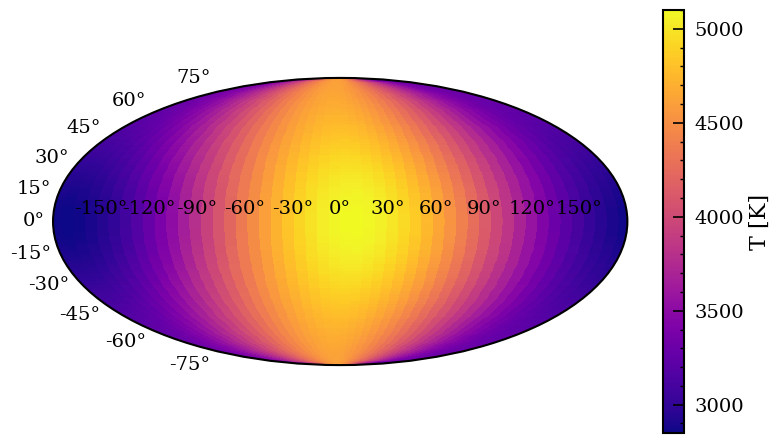

In [11]:
phases = np.linspace(0., 1., 10000)
xi = 2 * np.pi * (phases - 0.5)

## Parameters for creating meshgrid
phi_ang = np.linspace(-2 * np.pi, 2 * np.pi, 100)
theta_ang = np.linspace(0, np.pi, 100)
theta2d, phi2d = np.meshgrid(theta_ang, phi_ang)

## Computing the temperature map from the median posteriors
_, Tmap = thermal_phase_curve(
    xi=xi, hotspot_offset=np.nanmedian( res.posteriors['posterior_samples']['hotspotoff_p1'] ),\
        omega_drag=4.5, alpha=0.6, C_11=np.nanmedian( res.posteriors['posterior_samples']['cml11_p1'] ),\
        T_s=10170, a_rs=np.nanmedian(ar), rp_a=np.nanmedian(Rpa), A_B=0., theta2d=theta2d, phi2d=phi2d,\
        filt_wavelength=filt_wav['TESS82'], filt_transmittance=filt_trans['TESS82'],\
        f=np.nanmedian(res.posteriors['posterior_samples']['fprime_p1'])
)

## And plotting the temperature map
# Plot the temperature map
fig = plt.figure(figsize=(16/2, 9/2))
ax = fig.add_subplot(111, projection='mollweide')
cax = ax.pcolormesh(phi2d, theta2d - np.pi/2, Tmap[:,:,0,0])

plt.colorbar(cax, label='T [K]')
plt.tight_layout()

Fantastic!! Although it is great that we can fit physically motivated phase curve model to the data, the fitting is extremely time consuming. It took almost about 3 hours, and we were only using one TESS sector. We might want to fit more than one TESS sectors, or other datasets. In that case, the fitting can be really time consuming. There is a way out of this, as suggested by [Jones et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022A%26A...666A.118J/abstract).

The reason why the fitting is slow is that the model computation is expensive. We are now calculating the model for all times in our datasets, which is time consuming. What we can do is, we can evaluate the model on a regular grid of phases. We can then linearly interpolate the model to get the model at the times of our dataset. This can be done by providing number of grid points on phases as `kelp_thm_interpolation_knots` keyword in `juliet.fit`. We demonstrate this below: we will compute our model on regular grid of 150 phases, and then linearly interpolate them to evaluate model on the times of the dataset.

In [12]:
# Output folder
pout_inter = os.getcwd() + '/Analysis/Kelp_thm_inter'

# Juliet fitting
data_inter = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                         GP_regressors_lc=tim, out_folder=pout_inter)
res_inter = data_inter.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True,\
                           stellar_radius=2.362, kelp_thm_interpolation_knots=150,\
                           stellar_teff=10170, kelp_filt_wav=filt_wav, kelp_filt_trans=filt_trans,\
                           dynesty_save_states=True, checkpoint_every=5*60)#, dynesty_resume=True)

Detected dynamic_dynesty sampler output files --- extracting from /Users/japa6985/Documents/Codes/juliet-examples/Analysis/Kelp_thm_inter/_dynesty_DNS_posteriors.pkl


As you can see from above, it is super faster -- it only took about an hour, compared to roughly 3.5 hrs in the previous case. But does this compromise our posteriors somehow? So, let's compare the posteriors of phase curve parameters in both cases:

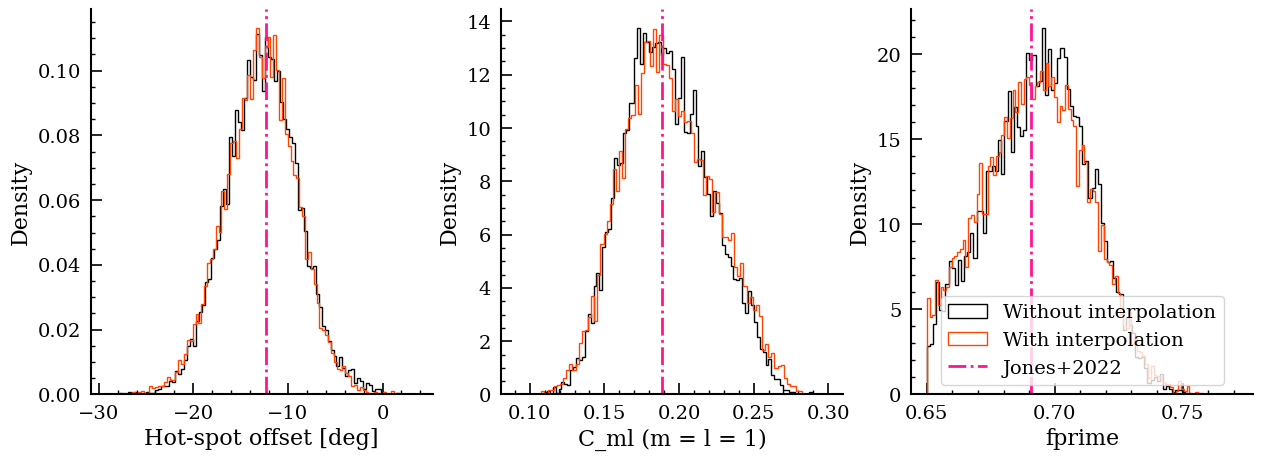

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
axs[0].hist(res.posteriors['posterior_samples']['hotspotoff_p1'], color='k', bins=100, histtype='step', density=True, label='Without interpolation');
axs[0].hist(res_inter.posteriors['posterior_samples']['hotspotoff_p1'], color='orangered', bins=100, histtype='step', density=True, label='With interpolation');
axs[0].axvline(-12.32, color='deeppink', ls='-.', label='Jones+2022')
axs[0].set_xlabel('Hot-spot offset [deg]')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['cml11_p1'], color='k', bins=100, histtype='step', density=True, label='Without interpolation');
axs[1].hist(res_inter.posteriors['posterior_samples']['cml11_p1'], color='orangered', bins=100, histtype='step', density=True, label='With interpolation');
axs[1].axvline(0.1884, color='deeppink', ls='-.', label='Jones+2022')
axs[1].set_xlabel('C_ml (m = l = 1)')
axs[1].set_ylabel('Density')

axs[2].hist(res.posteriors['posterior_samples']['fprime_p1'], color='k', bins=100, histtype='step', density=True, label='Without interpolation');
axs[2].hist(res_inter.posteriors['posterior_samples']['fprime_p1'], color='orangered', bins=100, histtype='step', density=True, label='With interpolation');
axs[2].axvline(0.690798, color='deeppink', ls='-.', label='Jones+2022')
axs[2].set_xlabel('fprime')
axs[2].set_ylabel('Density')
axs[2].legend(loc='lower center')

sns.despine()

Perfect! The posterior distribution of phase curve parameters when we perform interpolation and when we don't are essentially the same. Meaning that, our interpolation technique seems to work perfectly!